# Method: Graph community
The notebook comprises two parts. The first part creates the graph and determines the communities (clusters) according to the Louvain approach. The second part uses the `communities.json` file generated in the first part to retrieve the associated articles from a query, according to the algorithm depicted in the report.

## Data Loading - Graph Creation

In [1]:
import networkx as nx
from networkx.algorithms.community import louvain_communities
from networkx.algorithms.community.quality import modularity
import json
import matplotlib.pyplot as plt
from operator import itemgetter
from typing import Set, Dict, Any, Tuple
import os
import numpy as np

from operator import itemgetter # Utilisé pour trier

`FILTERED_JSON_PATH` allows you to select the subsampled dataset you want to use. This datasets are located in the folder `data/processed`.

In [ ]:
# --- Constants for file paths ---
FILTERED_JSON_PATH = 'data/processed/filtered_articles_Nmostcited.json'


def create_graph_from_filtered_json(
    json_path: str = FILTERED_JSON_PATH,
) -> nx.DiGraph:
    """
    Builds a directed graph (DiGraph) from the filtered JSON file.
    The graph is created in memory and is NOT saved or loaded from disk.
    """

    print("--- Creating graph from filtered JSON (in memory)... ---")
    
    G = nx.DiGraph()
    
    # 1. Load JSON data (Consolidated try/except)
    try:
        with open(json_path, 'r', encoding='utf-8') as json_file:
            data = json.load(json_file)
            
        articles = data.get('articles', [])
        
        # 2. Graph creation
        for article in articles:
            article_id = article.get('id')
            if article_id is not None:
                G.add_node(article_id) 
                for link in article.get('refs', []):
                    G.add_edge(article_id, link)
                    
             
    except FileNotFoundError:
        print(f"Error: Filtered JSON file not found at: {json_path}. Run 'filter_json_and_save' first.")
        return nx.DiGraph()
    except json.JSONDecodeError:
        print(f"Error: Invalid JSON format in file: {json_path}")
        return nx.DiGraph()
    except Exception as e:
        print(f"Error during graph creation: {e}")
        return nx.DiGraph()

    print(f"Graph created: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges.")
    
    return G

## Community generation

After community detection, a JSON file called `communities.json` is saved in the `data/processed` folder. This file contains all the Louvain clusters, along with the representative for each one, which is simply the most cited article in that cluster.

In [40]:
def community_detection():
    results = [] 
    G = create_graph_from_filtered_json()


    # Louvain community detection
    communities = louvain_communities(G, seed=42)

    for comm in communities:
        # Identify the node with the highest degree as the representative
        representative_article = sorted(comm, key=lambda x: G.in_degree(x), reverse=True)[0]
        results.append({
            'representative_node' : representative_article,
            # Convert set to list for JSON serialization
            'community' : list(comm) 
        })

    with open('data/processed/communities.json', 'w') as outfile:
        # Use indent for better JSON readability
        json.dump(results, outfile, indent=4) 

    return G, communities

if __name__ == '__main__':
    G, communities = community_detection()

--- Creating graph from filtered JSON (in memory)... ---
Graph created: 49919 nodes, 116528 edges.


In [30]:
file_path = 'data/processed/communities.json' 

with open(file_path, 'r') as infile:
    commu = json.load(infile)
print(len(commu))

article_name = {}
number_citation = {}
with open(FILTERED_JSON_PATH, 'r' ) as infile:
    nodes = json.load(infile)
for article in nodes['articles']:
    article_name[article['id']] = article['title']

48162


In [24]:
print('Number of clusters : ', len(commu))
print('Average number of article per cluster : ', np.mean([len(l['community']) for l in commu]))

print('---------')
print('LIST OF PROCESSED COMMUNITIES AND THEIR REPRESENTATIVE NODE')
print('---------')


for i,commu_i in enumerate(commu):
    print(f"Commu numéro {i+1} : {article_name[commu_i['representative_node']]}")


Number of clusters :  374
Average number of article per cluster :  133.6898395721925
---------
LIST OF PROCESSED COMMUNITIES AND THEIR REPRESENTATIVE NODE
---------
Commu numéro 1 : Planck 2013 results. XVI. Cosmological parameters
Commu numéro 2 : On $c_0$-saturated Banach spaces
Commu numéro 3 : Monopole Condensation, And Confinement In N=2 Supersymmetric Yang-Mills
  Theory
Commu numéro 4 : What is the gamma gamma resonance at 750 GeV?
Commu numéro 5 : Noninformative Quantum q-Priors
Commu numéro 6 : Primes in the denominators of Igusa Class Polynomials
Commu numéro 7 : Proposing Quantum Relativity and Finite Program
Commu numéro 8 : The Quantum Schur Transform: I. Efficient Qudit Circuits
Commu numéro 9 : Fermion-boson duality in integrable quantum field theory
Commu numéro 10 : The Catalina Real-Time Transient Survey (CRTS)
Commu numéro 11 : A Survey on Multi-Task Learning
Commu numéro 12 : A Study of Quasi-Exactly Solvable Models within the Quantum
  Hamilton-Jacobi Method
Commu 

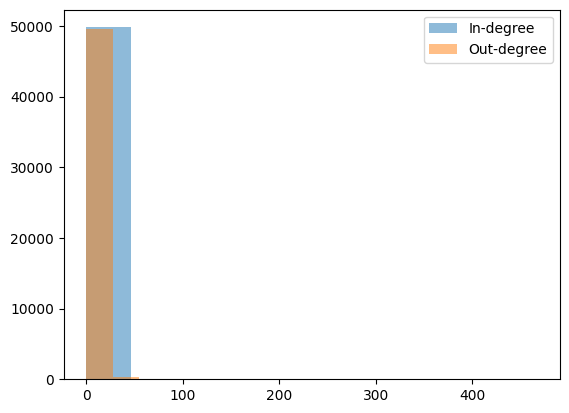

In [41]:
# Compact plot
plt.hist([d for n, d in G.in_degree()], alpha=0.5, label='In-degree')
plt.hist([d for n, d in G.out_degree()], alpha=0.5, label='Out-degree')
plt.legend()
plt.show()

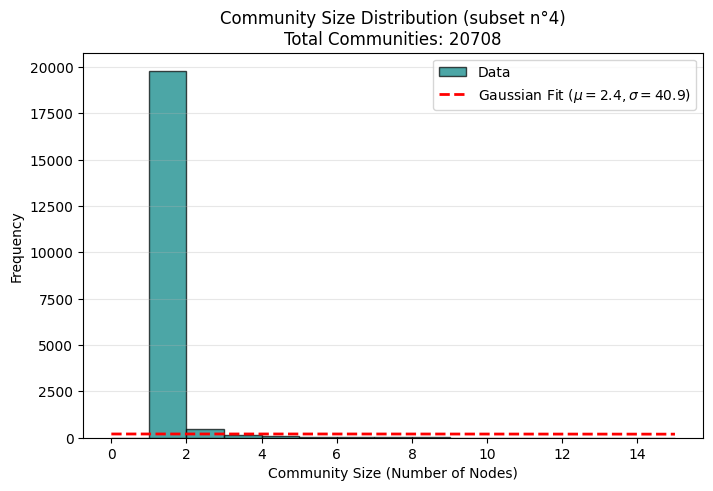

In [57]:
from scipy.stats import norm
# 1. Calculate sizes
comm_sizes = [len(c) for c in communities]
total_communities = len(communities)

# --- Gaussian Fit Calculation ---
mu, std = norm.fit(comm_sizes) # Fit the data (mean and std dev)
x = np.linspace(0, 15, 100)    # X-axis range for the line
p = norm.pdf(x, mu, std)       # Probability Density Function

# Scaling: PDF * Total_Count * Bin_Width
# Since range is (0,15) and bins=15, Bin_Width = 1. 
# So we simply multiply by total_communities.
p_scaled = p * total_communities 

# 2. Plot Distribution
plt.figure(figsize=(8, 5))

# Plot Histogram
plt.hist(comm_sizes, bins=15, range=(0,15), color='teal', edgecolor='black', alpha=0.7, label='Data')

# Plot Gaussian
plt.plot(x, p_scaled, 'r--', linewidth=2, label=f'Gaussian Fit ($\mu={mu:.1f}, \sigma={std:.1f}$)')

# Labels
plt.title(f"Community Size Distribution (subset n°4)\nTotal Communities: {total_communities}")
plt.xlabel("Community Size (Number of Nodes)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

## Recommandation

Once the communities have been processed, the closest article to the query is found using a retrieval method (here embedding method), and the representative article of the community in which the node participates is associated with it.

In [13]:
# Core Python libraries
import numpy as np
import pandas as pd
from tqdm import tqdm
import json
import re
import os

# NLP and Embeddings
from sentence_transformers import SentenceTransformer
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
import faiss


# Visualization and evaluation
import matplotlib.pyplot as plt
import seaborn as sns



Fist, the ebedding is created for the subset.

In [14]:
def compute_and_save_embeddings(texts, doc_ids, model_name='all-mpnet-base-v2',
                                batch_size=64, out_emb_path='embeddings.npy',
                                out_ids_path='doc_ids.json', overwrite=True):
    if os.path.exists(out_emb_path) and not overwrite:
        raise FileExistsError(f"{out_emb_path} already exists. Set overwrite=True to replace.")

    model = SentenceTransformer(model_name)
    n = len(texts)
    emb_dim = model.get_sentence_embedding_dimension()

    emb_memmap = np.lib.format.open_memmap(out_emb_path, mode='w+', dtype='float32', shape=(n, emb_dim))

    for i in tqdm(range(0, n, batch_size), desc="Embedding batches"):
        batch_texts = texts[i:i+batch_size]
        batch_emb = model.encode(batch_texts, show_progress_bar=False, convert_to_numpy=True)
        # normalize rows to unit vectors (for cosine via inner product)
        norms = np.linalg.norm(batch_emb, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        batch_emb = batch_emb / norms
        emb_memmap[i:i+len(batch_emb)] = batch_emb.astype('float32')

    # ensure data flushed to disk
    del emb_memmap

    # save doc ids as JSON
    with open(out_ids_path, 'w', encoding='utf-8') as f:
        json.dump(list(doc_ids), f, ensure_ascii=False)

    print(f"Saved embeddings -> {out_emb_path}")
    print(f"Saved doc ids -> {out_ids_path}")

In [ ]:
from sentence_transformers import SentenceTransformer

# Define output paths variables to ensure consistency
output_emb_file = 'data/processed/embeddings.npy'
output_ids_file = 'data/processed/doc_ids.json'

# Check if the output files already exist
if os.path.exists(output_emb_file) and os.path.exists(output_ids_file):
    # Files exist: Skip the expensive computation
    print(f"Embeddings and IDs found at '{output_emb_file}'. Skipping computation.")
else:
    # Files do not exist: Proceed with loading data and computing embeddings
    print("Output files not found. Starting data loading and embedding computation...")

    with open(FILTERED_JSON_PATH, 'r', encoding='utf-8') as f:
        data = json.load(f)

    texts = [article["clean_text"] for article in data["articles"]]
    doc_ids = [article["id"] for article in data["articles"]]

    model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

    # Call the function
    compute_and_save_embeddings(
        texts,
        doc_ids,
        model_name='all-MiniLM-L6-v2',
        batch_size=8,
        out_emb_path=output_emb_file,
        out_ids_path=output_ids_file,
        overwrite=True
    )
    print("Computation finished and files saved.")

# Loading and verification (Load from the specific paths defined above)
print("-" * 30)
print("Verifying loaded data...")

loaded_emb = np.load(output_emb_file, mmap_mode='r')
with open(output_ids_file, 'r', encoding='utf-8') as f:
    loaded_ids = json.load(f)

print("Embeddings shape:", loaded_emb.shape)
print("Number of doc ids:", len(loaded_ids))
print("Example embedding (first doc) first 10 dims:", loaded_emb[0][:10])

Output files not found. Starting data loading and embedding computation...


Embedding batches: 100%|██████████| 6240/6240 [20:56<00:00,  4.97it/s]

Saved embeddings -> data/processed/embeddings.npy
Saved doc ids -> data/processed/doc_ids.json
Computation finished and files saved.
------------------------------
Verifying loaded data...
Embeddings shape: (49919, 384)
Number of doc ids: 49919
Example embedding (first doc) first 10 dims: [-0.08914597  0.03614483 -0.02356093  0.02534425 -0.03705267 -0.02898317
  0.07373413 -0.0226588   0.00625514 -0.05217345]


A FAISS index is used.

In [17]:
def build_faiss_index(embeddings_path='data/processed/embeddings.npy', index_path='data/processed/faiss.index',
                      index_type='hnsw', ef_construction=200, M=32):
    emb = np.load(embeddings_path, mmap_mode='r')  # shape (N, d)
    d = emb.shape[1]
    if index_type == 'flat':
        index = faiss.IndexFlatIP(d)  # inner product -> cosine if vectors normalized
        index.add(emb)
    elif index_type == 'hnsw':
        index = faiss.IndexHNSWFlat(d, M)  # M controls connectivity
        index.hnsw.efConstruction = ef_construction
        index.add(emb)
    else:
        raise ValueError('index_type not supported')
    faiss.write_index(index, index_path)
    return index

In [18]:
def retrieve_similar_articles(query, model, embeddings, articles, top_n=5, use_ann=False):
    query_emb = model.encode([query], convert_to_numpy=True)
    # normalize
    query_emb = query_emb / np.linalg.norm(query_emb, axis=1, keepdims=True)
    
    if use_ann:
        index = build_faiss_index()
        distances, indices = index.search(query_emb.astype('float32'), top_n)
    else:
        # Exact search using sklearn
        nbrs = NearestNeighbors(n_neighbors=top_n, metric="cosine").fit(embeddings)
        distances, indices = nbrs.kneighbors(query_emb)
    
    results = pd.DataFrame({
        "article_id": [articles[i] for i in indices[0]],
        "similarity": [1 - d for d in distances[0]]
    })
    return results

In [19]:
def get_representative(member_id, file_path="data/processed/communities.json"):
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        for group in data:
            if member_id in group.get("community", []):
                return group["representative_node"]
                
        return None

    except (FileNotFoundError, json.JSONDecodeError):
        return None

In [22]:
query  ="I am a scientist"


top_n = 1

embeddings = np.load('data/processed/embeddings.npy', mmap_mode='r')
results = retrieve_similar_articles(query, model, embeddings, doc_ids, top_n, use_ann=True)

print('QUERY :')
print(query)
print("---")

print(f"Closest article")
print(article_name[results['article_id'][0]])
print("----")

print("Represenrative article")
representative = get_representative(results['article_id'][0])
print(article_name[representative])


QUERY :
I am a scientist
---
Closest article
Crowdsourced science: sociotechnical epistemology in the e-research
  paradigm
----
Represenrative article
Crowdsourced science: sociotechnical epistemology in the e-research
  paradigm


For evaluation purposes, it may be relevant to see if the response proposed by the method is at least in the same cluster as the one we were aiming for. This allows for a more refined approach than simply saying whether the article is correct or not. This is exactly what the function below does. (It even gives the minimum distance between articles in case they are related (otherwise None) -> not yet i i am not even sure it is interesting...).

In [36]:
def common_commu(result_id, target_id):
    # are the result_id and the tardget_id in the same community / cluster ?
    COM_FILE = 'data/processed/communities.json'
    with open(COM_FILE, 'r') as file:
        commu = json.load(file)
    
    for commu_l in commu:
        if result_id in commu_l['community'] and target_id in commu_l['community']:
            return True
    
    return False